In [ ]:
install.packages("psych")
install.packages("ggpubr")
install.packages("PMCMR")
install.packages('caret')
install.packages('dplyr')
install.packages('leaps')
install.packages('lattice')

In [5]:
library(psych)    # Paquete para análisis estadístico.
library(cowplot)  # Combina múltiples gráficos de ggplot2.
library(rstatix)  # Simplifica análisis estadísticos comunes.
library(ggpubr)   # Facilita la creación de gráficos.
library(ggplot2)  # Sistema para crear gráficos.
library(car)      # Herramientas para análisis de regresión avanzada.
library(PMCMR)    # Pruebas no paramétricas para comparaciones múltiples.
library(dplyr)    # Manipulación de datos eficiente.
library(tidyr)    # Herramientas para reorganizar datos.
library(leaps)    # Selección de subconjuntos en regresión.
library(caret)    # Herramientas unificadas para machine learning.

1) read.csv(): Función de R para leer archivos CSV y cargarlos en un data frame.

2) url: Ubicación del archivo CSV que se va a leer, puede ser una URL en línea o una ruta local en el sistema de archivos.

3) header = F: Argumento que indica si el archivo CSV tiene una fila de encabezado. F significa que no hay encabezado.

4) sep = ",": Especifica el separador de campo utilizado en el archivo CSV, en este caso, se usa la coma.

5) col.names = columns: Especifica los nombres de las columnas del data frame resultante.


In [2]:
columns = c("area", "perimeter", "compactness", "length", "width", "AC", "lengthGroove", "class")

In [3]:
url = "https://www.dl.dropboxusercontent.com/s/wrexlo5im3g5ioi/seeds_dataset.csv"

In [4]:
seeds = read.csv(url, header = F, sep=",", col.names = columns)

In [10]:
head(seeds)

,area,perimeter,compactness,length,width,AC,lengthGroove,class
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
6,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1


# seeds$class: Se aAccede a la columna "class" existente en el data frame con nombre seeds y se transforma la misma en un factor().  Estos son útiles para representar variables categóricas en R.

Sintaxis
```
factor(x = character(),         # Vector de entrada
       levels,                  # Valores únicos de x (opcional)
       labels = levels,         # Etiquetas para los niveles (opcional)
       exclude = NA,            # Valores a excluir de los niveles
       ordered = is.ordered(x), # Si los niveles de entrada están ordenados o no
       nmax = NA)               # Máximo número de niveles
```

In [11]:
seeds$class = factor(seeds$class, levels = c(1,2,3), labels = c("Kama", "Rosa", "Canadian"))

# Inspeccionamos los primeros elementos del data frame seeds

In [ ]:
head(seeds)

,area,perimeter,compactness,length,width,AC,lengthGroove,class
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama
6,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,Kama


# Inspeccionamos los últimos elementos del data frame seeds

In [ ]:
tail(seeds)

,area,perimeter,compactness,length,width,AC,lengthGroove,class
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
205,12.37,13.47,0.8567,5.204,2.960,3.919,5.001,Canadian
206,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,Canadian
207,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,Canadian
208,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,Canadian
209,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,Canadian
210,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,Canadian


Accedemos a la columna perimeter y obtenemos la media

Para obtener los estadísticos descriptivos del data frame seeds en R, puedes utilizar la función summary() o describe() de la librería psych. Aquí te muestro ambas opciones:

In [ ]:
summary(seeds)

      area         perimeter      compactness         length     
 Min.   :10.59   Min.   :12.41   Min.   :0.8081   Min.   :4.899  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:0.8569   1st Qu.:5.262  
 Median :14.36   Median :14.32   Median :0.8734   Median :5.524  
 Mean   :14.85   Mean   :14.56   Mean   :0.8710   Mean   :5.629  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:0.8878   3rd Qu.:5.980  
 Max.   :21.18   Max.   :17.25   Max.   :0.9183   Max.   :6.675  
     width             AC          lengthGroove        class   
 Min.   :2.630   Min.   :0.7651   Min.   :4.519   Kama    :70  
 1st Qu.:2.944   1st Qu.:2.5615   1st Qu.:5.045   Rosa    :70  
 Median :3.237   Median :3.5990   Median :5.223   Canadian:70  
 Mean   :3.259   Mean   :3.7002   Mean   :5.408                
 3rd Qu.:3.562   3rd Qu.:4.7687   3rd Qu.:5.877                
 Max.   :4.033   Max.   :8.4560   Max.   :6.550                

# trimmed:
Una media recortada es la media de un conjunto de datos que se ha calculado después de eliminar un porcentaje específico de los valores más pequeños y más grandes del conjunto de datos.

Por ejemplo, una media recortada del 10 % representaría la media de un conjunto de datos después de que se hayan eliminado el 10 % de los valores más pequeños y el 10 % de los valores más grandes.

# mad:
Determina la desviación absoluta mediana, esta mide la dispersión de un conjunto de datos. Es una alternativa robusta a la desviación tipica y al rango intercuartílico siendo menos sensible a los valores atípicos.

1. **vars**: Número de variables en el data frame o conjunto de datos analizado.
2. **n**: Número de observaciones disponibles para cada variable. Para el caso 210.
3. **mean**: Media aritmética de cada variable.
4. **sd**: Desviación estándar de cada variable. Esta mide la dispersión de los datos alrededor de la media.
5. **median**: La mediana de cada variable, es el valor en el cual se encuentra el punto medio de un conjunto de datos ordenados.
6. **trimmed**: Medida recortada de cada variable. Es la media calculada después de eliminar un cierto porcentaje de los valores extremos en cada extremo del conjunto de datos.
7. **mad**: Desviación absoluta de la mediana de cada variable. Medida de dispersión robusta similar a la desviación estándar pero menos sensible a los valores atípicos.
8. **min**: Es el valor mínimo observado para cada variable.
9. **max**: Es el valor máximo observado para cada variable.
10. **range**: Es el rango de cada variable. Se calcula como la diferencia entre el valor máximo y el valor mínimo.
11. **skew**: Asimetría de cada variable. Indica la falta de simetría en la distribución de los datos.
12. **kurtosis**: Curtosis de cada variable, mide la forma de la distribución de los datos. Valores positivos indican una distribución más puntiaguda (más picos) que una distribución normal, mientras que valores negativos indican una distribución más aplanada.
13. **se**: Error estándar de la media para cada variable. Indica la precisión de la estimación de la media muestral.

In [ ]:
describe(seeds)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
area,1,210,14.8475238,2.90969943,14.35500,14.699464,3.33585000,10.5900,21.1800,10.5900,0.3941946,-1.1052328,0.200788337
perimeter,2,210,14.5592857,1.30595873,14.32000,14.493690,1.49001300,12.4100,17.2500,4.8400,0.3810678,-1.1269312,0.090119714
compactness,3,210,0.8709986,0.02362942,0.87345,0.872544,0.02216487,0.8081,0.9183,0.1102,-0.5302931,-0.1923636,0.001630585
length,4,210,5.6285333,0.44306348,5.52350,5.597518,0.47517330,4.8990,6.6750,1.7760,0.5179985,-0.8164443,0.030574285
width,5,210,3.2586048,0.37771444,3.23700,3.252095,0.47369070,2.6300,4.0330,1.4030,0.1324647,-1.1182220,0.026064773
AC,6,210,3.7002010,1.50355713,3.59900,3.643202,1.66718370,0.7651,8.4560,7.6909,0.3959475,-0.1210795,0.103755299
lengthGroove,7,210,5.4080714,0.49148050,5.22300,5.377470,0.38992380,4.5190,6.5500,2.0310,0.5538958,-0.8697756,0.033915377
class*,8,210,2.0000000,0.81844759,2.00000,2.000000,1.48260000,1.0000,3.0000,2.0000,0.0000000,-1.5142517,0.056478249


In [ ]:
str(seeds)

'data.frame':	210 obs. of  8 variables:
 $ area        : num  15.3 14.9 14.3 13.8 16.1 ...
 $ perimeter   : num  14.8 14.6 14.1 13.9 15 ...
 $ compactness : num  0.871 0.881 0.905 0.895 0.903 ...
 $ length      : num  5.76 5.55 5.29 5.32 5.66 ...
 $ width       : num  3.31 3.33 3.34 3.38 3.56 ...
 $ AC          : num  2.22 1.02 2.7 2.26 1.35 ...
 $ lengthGroove: num  5.22 4.96 4.83 4.8 5.17 ...
 $ class       : Factor w/ 3 levels "Kama","Rosa",..: 1 1 1 1 1 1 1 1 1 1 ...


La línea `sapply(seeds, is.numeric)` aplica una verificación para identificar qué columnas del data frame `seeds` son numéricas, devolviendo un vector de valores `TRUE` o `FALSE`. Luego, la notación de subconjuntos `seeds[, sapply(seeds, is.numeric)]` se emplea para seleccionar y mantener solo esas columnas numéricas de `seeds`, incluyendo todas sus filas.

In [6]:
# Seleccionar solo las columnas numéricas
numeric_seeds <- seeds[, sapply(seeds, is.numeric)]

# Calcular la correlación
correlation_matrix <- cor(numeric_seeds)
correlation_matrix

,area,perimeter,compactness,length,width,AC,lengthGroove,class
area,1.0000000,0.9943409,0.6082884,0.9499854,0.9707706,-0.22957233,0.86369275,-0.34605787
perimeter,0.9943409,1.0000000,0.5292436,0.9724223,0.9448294,-0.21734037,0.89078390,-0.32789970
compactness,0.6082884,0.5292436,1.0000000,0.3679151,0.7616345,-0.33147087,0.22682482,-0.53100702
length,0.9499854,0.9724223,0.3679151,1.0000000,0.8604149,-0.17156243,0.93280609,-0.25726870
width,0.9707706,0.9448294,0.7616345,0.8604149,1.0000000,-0.25803655,0.74913147,-0.42346287
AC,-0.2295723,-0.2173404,-0.3314709,-0.1715624,-0.2580365,1.00000000,-0.01107902,0.57727271
lengthGroove,0.8636927,0.8907839,0.2268248,0.9328061,0.7491315,-0.01107902,1.00000000,0.02430104
class,-0.3460579,-0.3278997,-0.5310070,-0.2572687,-0.4234629,0.57727271,0.02430104,1.00000000


In [ ]:
heatmap(correlation_matrix,
        symm = TRUE,
        margins = c(9, 9))

# Outliers

In [16]:
detectar_valores_atipicos_tukey <- function(data, columna) {
  # Calcular los cuartiles Q1 y Q3
  q1 <- quantile(data[[columna]], 0.25)
  q3 <- quantile(data[[columna]], 0.75)
  # Calcular el rango intercuartílico (IQR)
  iqr <- q3 - q1
  # Calcular los límites para detectar valores atípicos según el método de Tukey
  limite_inferior <- q1 - 1.5 * iqr
  limite_superior <- q3 + 1.5 * iqr
  # Identificar los valores atípicos
  ati_tukey <- data[[columna]] < limite_inferior | data[[columna]] > limite_superior
  # Obtener los índices de los valores atípicos
  indices_atipicos <- which(ati_tukey)
  # Retornar los índices de los valores atípicos
  return(indices_atipicos)
}

In [17]:
columnas <- c("area", "perimeter", "compactness", "length", "width", "AC", "lengthGroove")

for (col in columnas) {
  indices_atipicos <- detectar_valores_atipicos_tukey(seeds, col)
  cat("Columna:", col, "\n")
  cat("Índices de valores atípicos:", indices_atipicos, "\n\n")
}

Columna: area 
Índices de valores atípicos:  

Columna: perimeter 
Índices de valores atípicos:  

Columna: compactness 
Índices de valores atípicos: 158 159 175 

Columna: length 
Índices de valores atípicos:  

Columna: width 
Índices de valores atípicos:  

Columna: AC 
Índices de valores atípicos: 204 208 

Columna: lengthGroove 
Índices de valores atípicos:  



`boxplot.width <- ggboxplot(data = seeds, x = "class", y = "width", color = "class") + border()`. Gráfico de cajas en R utilizando la librería `ggplot2`. `ggboxplot()`. Función que genera el gráfico, se designa `seeds` como la fuente de datos. La variable "class" se usa para formar los grupos en el eje x, mientras que "width" es la medida que se muestra en el eje y. Además, "class" coloreará los grupos de forma diferenciada y `+ border()` se añade para delinear cada elemento gráficamente.

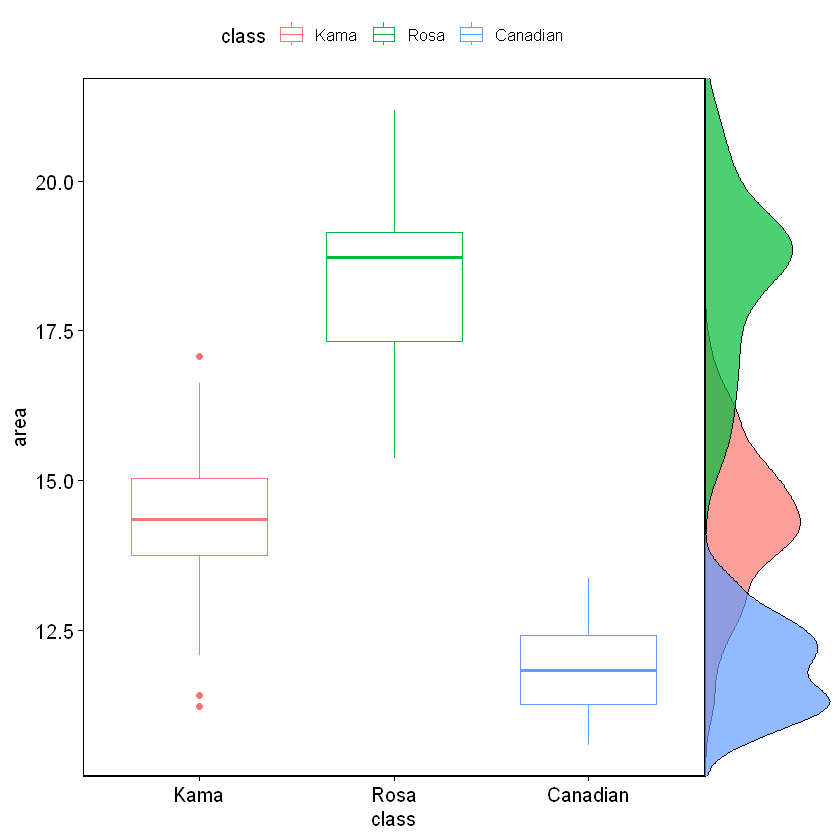

In [27]:
boxplot.width <- ggboxplot(data = seeds, x = "class", y = "area", color = "class") + border()
ydens <- axis_canvas(boxplot.width, axis = "y", coord_flip = TRUE) +
  geom_density(data = seeds, aes(x = get("area"), fill = get("class")), alpha = 0.7, linewidth = 0.2) +
  coord_flip()
boxplot.width <- insert_yaxis_grob(boxplot.width, ydens, grid::unit(.2, "null"), position = "right")
ggdraw(boxplot.width)

# Pruebas de comparación de grupos:

1) Prueba t de Student: Al usar una prueba t, se pueden comparar las medias de dos grupos. Esto con el objetivo de saber si hay una diferencia significativa entre ellos.

Hipótesis nula (H0): La hipótesis nula establece que, no existe diferencia significativa entre las medias del área entre los grupos "Kama" y "Rosa".

# H0:μKama=μRosaH0​

Hipótesis alternativa (H1): La hipótesis alternativa indica que, hay una diferencia significativa entre las medias del área entre los grupos "Kama" y "Rosa".

# H1:μKama≠μRosaH1​

In [28]:
# Crear una lista para almacenar los resultados de la prueba t para cada par de clases
t_test_results <- list()

# Combinaciones de clases
class_combinations <- combn(levels(seeds$class), 2)

# Iterar sobre cada par de clases
for (i in seq_len(ncol(class_combinations))) {
  # Extraer las dos clases de la combinación
  class_pair <- class_combinations[, i]
  # Filtrar el data frame para las clases actuales
  seeds_sub <- subset(seeds, class %in% class_pair)
  # Realizar la prueba t para las clases actuales
  t_test_result <- t.test(area ~ class, data = seeds_sub)
  # Almacenar el resultado en la lista
  t_test_results[[paste(class_pair, collapse = "-")]] <- t_test_result
  }
  # Imprimir los resultados
  t_test_results

$`Kama-Rosa`

	Welch Two Sample t-test

data:  area by class
t = -17.761, df = 134.24, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Kama and group Rosa is not equal to 0
95 percent confidence interval:
 -4.445258 -3.554456
sample estimates:
mean in group Kama mean in group Rosa 
          14.33443           18.33429 


$`Kama-Canadian`

	Welch Two Sample t-test

data:  area by class
t = 14.555, df = 112.38, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Kama and group Canadian is not equal to 0
95 percent confidence interval:
 2.125615 2.795528
sample estimates:
    mean in group Kama mean in group Canadian 
              14.33443               11.87386 


$`Rosa-Canadian`

	Welch Two Sample t-test

data:  area by class
t = 33.555, df = 101.73, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Rosa and group Canadian is not equal to 0
95 percent confidence interval:
 6.078524 6.842333
s

# t.test -- >

Significación estadística: En general, se establece un umbral de significancia (alfa), comúnmente 0.05, para interpretar el valor p. Si el valor p es menor que este umbral, se considera que los resultados son estadísticamente significativos, lo que sugiere que hay suficiente evidencia para rechazar la hipótesis nula en favor de la hipótesis alternativa. Por otro lado, si el valor p es mayor que el umbral de significancia, no hay suficiente evidencia para rechazar la hipótesis nula.

El valor p es muy pequeño (cercano a cero), lo que indica que hay una evidencia muy fuerte en contra de la hipótesis nula. En consecuencia, se rechaza la hipótesis nula y se concluye que hay una diferencia significativa entre las medias de los grupos "Kama" y "Rosa".

# Por lo tanto, hay evidencia suficiente en los datos para afirmar que las dos muestras ("Kama" y "Rosa") no provienen de la misma población.

Si las muestras de semillas de las variedades "Kama" y "Rosa" fueran tomadas de una misma población homogénea, esperaríamos que cualquier diferencia observada entre las características (por ejemplo, área, longitud, anchura, etc.) de las semillas de ambas variedades fuera el resultado del azar. En otras palabras, no esperaríamos diferencias significativas entre las dos variedades más allá de la variabilidad natural que encontraríamos al seleccionar muestras aleatorias de una misma población de semillas.

Sin embargo, si realizamos análisis estadísticos y encontramos diferencias significativas en las características de las semillas entre las variedades "Kama" y "Rosa", esto sugiere que las semillas de cada variedad tienen características distintivas que hacen que sus medidas sean diferentes. Estas diferencias observadas no pueden atribuirse únicamente al azar, sino que sugieren que hay diferencias sistemáticas entre las variedades en términos de las características medidas.


# test de normalidad (Shapiro-Wilk) -->


Si el p-value es menor que un nivel de significancia predefinido (usualmente 0.05), entonces se rechaza la hipótesis nula de que los datos provienen de una distribución normal, lo que indica que los datos no son normales.
  
# Hipótesis nula (H0): Los datos siguen una distribución normal.
# Hipótesis alternativa (H1): Los datos no siguen una distribución normal.

Si el p-value es menor que el nivel de significancia (por ejemplo, 0.05), se rechaza la hipótesis nula y se concluye que los datos no siguen una distribución normal. Por otro lado, si el p-value es mayor que el nivel de significancia, no hay suficiente evidencia para rechazar la hipótesis nula y se concluye que los datos pueden seguir una distribución normal.

In [ ]:
# Longitud dinámica: seq_along(). Si el objeto cambia de tamaño, seq_along() se ajusta automáticamente a la longitud de la secuencia.
# lapply() en R se utiliza para aplicar una función a cada elemento de una lista (o vector) y devuelve una lista con los resultados de aplicar esa función a cada elemento.

# Realizar el test de normalidad de Shapiro-Wilk para cada variable numérica en el dataframe seeds
shapiro_test_results <- lapply(numeric_seeds, shapiro.test)

shapiro_test_results


$area

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.93259, p-value = 2.948e-08


$perimeter

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.93616, p-value = 5.902e-08


$compactness

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.97304, p-value = 0.0004696


$length

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.9438, p-value = 2.828e-07


$width

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.96062, p-value = 1.445e-05


$AC

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.98362, p-value = 0.01544


$lengthGroove

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.92494, p-value = 7.142e-09



In [ ]:
# Resultados
for (i in seq_along(shapiro_test_results)) {
  variable_name <- names(numeric_seeds)[i]
  test_result <- shapiro_test_results[[i]]
  cat("Variable:", variable_name, "\n")
  cat("Test Statistic:", test_result$statistic, "\n")
  cat("p-value:", test_result$p.value, "\n")
  # Se usa la función ifelse() para determinar si p < al umbral de significancia
  cat("Normality Test:", ifelse(test_result$p.value < 0.05, "Not Normal", "Normal"), "\n")
  cat("\n")
}

Variable: area 
Test Statistic: 0.9325935 
p-value: 2.947712e-08 
Normality Test: Not Normal 

Variable: perimeter 
Test Statistic: 0.9361616 
p-value: 5.90217e-08 
Normality Test: Not Normal 

Variable: compactness 
Test Statistic: 0.9730421 
p-value: 0.0004696481 
Normality Test: Not Normal 

Variable: length 
Test Statistic: 0.9437987 
p-value: 2.827879e-07 
Normality Test: Not Normal 

Variable: width 
Test Statistic: 0.9606235 
p-value: 1.444632e-05 
Normality Test: Not Normal 

Variable: AC 
Test Statistic: 0.9836223 
p-value: 0.01543933 
Normality Test: Not Normal 

Variable: lengthGroove 
Test Statistic: 0.9249415 
p-value: 7.141672e-09 
Normality Test: Not Normal 



# La prueba F es útil para probar si dos varianzas poblacionales son iguales

Hipótesis Nula (H0): Las varianzas de las áreas en las clases "Kama" y "Rosa" son iguales.

Hipótesis Alternativa (H1): Las varianzas de las áreas en las clases "Kama" y "Rosa" son diferentes.

In [ ]:
# Lista para almacenar los resultados de las pruebas de varianza
var_test_results <- list()

# Iterar sobre cada par de clases
for (i in seq_len(ncol(class_combinations))) {
  # Extraer las dos clases de la combinación
  class_pair <- class_combinations[, i]

  # Filtrar el dataframe para las clases actuales
  seeds_subset <- subset(seeds, class %in% class_pair)

  # Realizar la prueba de varianza
  var_test_result <- var.test(area ~ class, data = seeds_subset)

  # Almacenar el resultado en la lista
  var_test_results[[paste(class_pair, collapse = "-")]] <- var_test_result
}

# Imprimir los resultados
for (result_name in names(var_test_results)) {
  cat("Resultados para la combinación:", result_name, "\n")
  print(var_test_results[[result_name]])
}

Resultados para la combinación: Kama-Rosa 

	F test to compare two variances

data:  area by class
F = 0.71324, num df = 69, denom df = 69, p-value = 0.163
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.4431861 1.1478428
sample estimates:
ratio of variances 
         0.7132377 

Resultados para la combinación: Kama-Canadian 

	F test to compare two variances

data:  area by class
F = 2.8273, num df = 69, denom df = 69, p-value = 2.553e-05
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 1.756816 4.550117
sample estimates:
ratio of variances 
          2.827317 

Resultados para la combinación: Rosa-Canadian 

	F test to compare two variances

data:  area by class
F = 3.9641, num df = 69, denom df = 69, p-value = 3.878e-08
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 2.463157 6.379524
sample estimates:
ratio of variances 
         

Si se encuentra suficiente evidencia para afirmar que hay una diferencia significativa en las varianzas, implica que las clases "Kama" y "Rosa" tienen diferentes niveles de variabilidad en cuanto al tamaño de las áreas de las semillas. Existiendo una diferencia en la distribución o en la dispersión de los datos entre estas clases.

# ANOVA

El análisis de varianza (ANOVA) se utiliza para comparar las medias de tres o más grupos diferentes y determinar si al menos uno de esos grupos difiere significativamente de los demás en términos de la variable de interés.

Se utiliza ANOVA cuando tenemos una variable independiente categórica (también conocida como factor) con tres o más niveles y una variable dependiente continua. El objetivo principal del ANOVA es determinar si existe una diferencia significativa en las medias de la variable dependiente entre los diferentes niveles de la variable independiente

Análisis de varianza (ANOVA): Si se tienen dos o más se puede hacer una comparación entre las medias. Para ellos se puede utilizar un ANOVA y determinar si hay diferencias significativas entre los grupos.

La cantidad de variabilidad explicada por el modelo y los grados de libertad asociados con cada término, así como los valores F y p asociados con el ANOVA para el factor "class". El valor extremadamente pequeño de p indica que hay diferencias significativas entre los grupos en función del tipo de semilla

In [ ]:
# Ejecutar el ANOVA
anova_result <- aov(area ~ class, data = seeds)
# Mostrar solo los valores p
summary(anova_result)


             Df Sum Sq Mean Sq F value Pr(>F)    
class         2   1488   744.2   548.2 <2e-16 ***
Residuals   207    281     1.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
names(anova_result)

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "contrasts"     "xlevels"       "call"          "terms"        
[13] "model"

In [ ]:
# Realizar la prueba Tukey's HSD
intervals = TukeyHSD(anova_result)
intervals

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = area ~ class, data = seeds)

$class
                   diff       lwr       upr p adj
Rosa-Kama      3.999857  3.534921  4.464793     0
Canadian-Kama -2.460571 -2.925507 -1.995635     0
Canadian-Rosa -6.460429 -6.925365 -5.995493     0


Explica las diferencias existentes por grupo. ¿Algunas de estas diferencias son significativas?

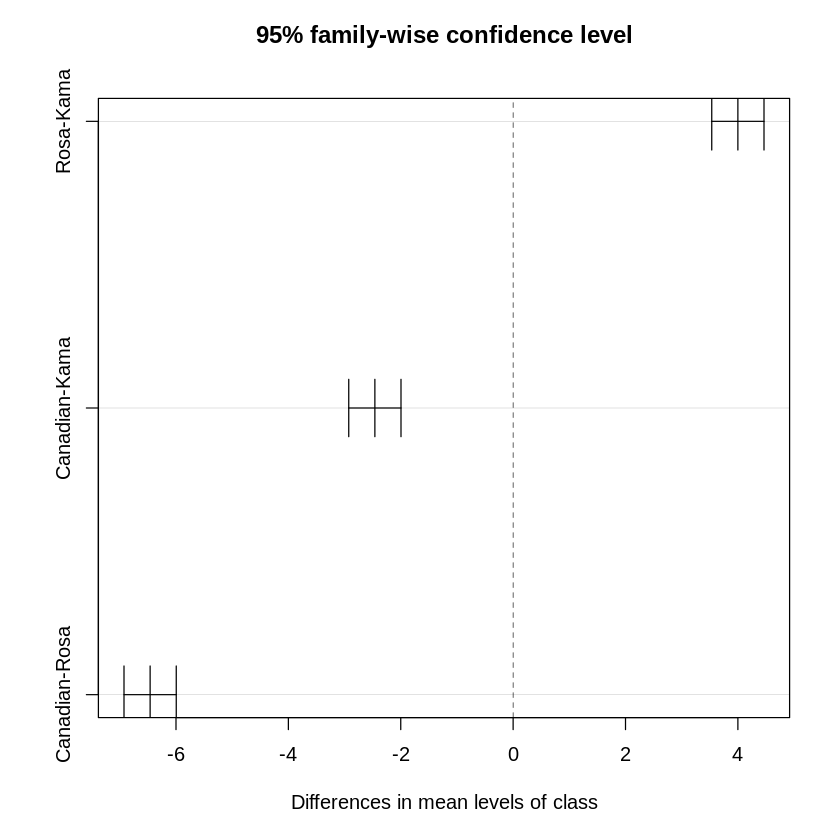

In [ ]:
plot(intervals)

# Validación del modelo ANOVA

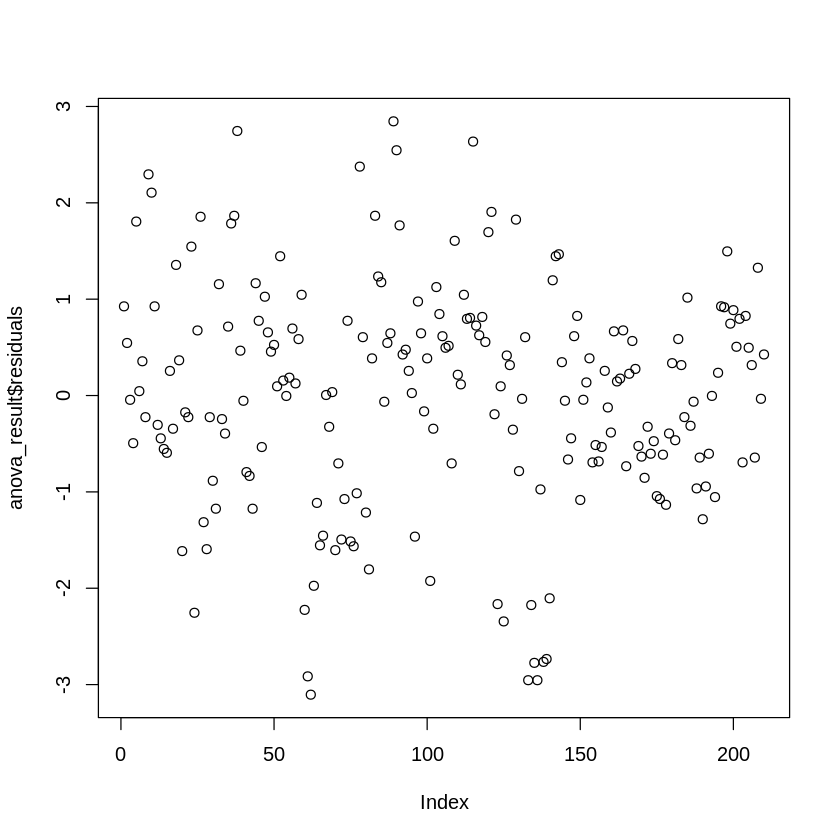

In [ ]:
# Independencia
plot(anova_result$residuals)


# Normalidad

In [ ]:
summary(anova_result$residuals)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.1044 -0.6589  0.1057  0.0000  0.6907  2.8457 

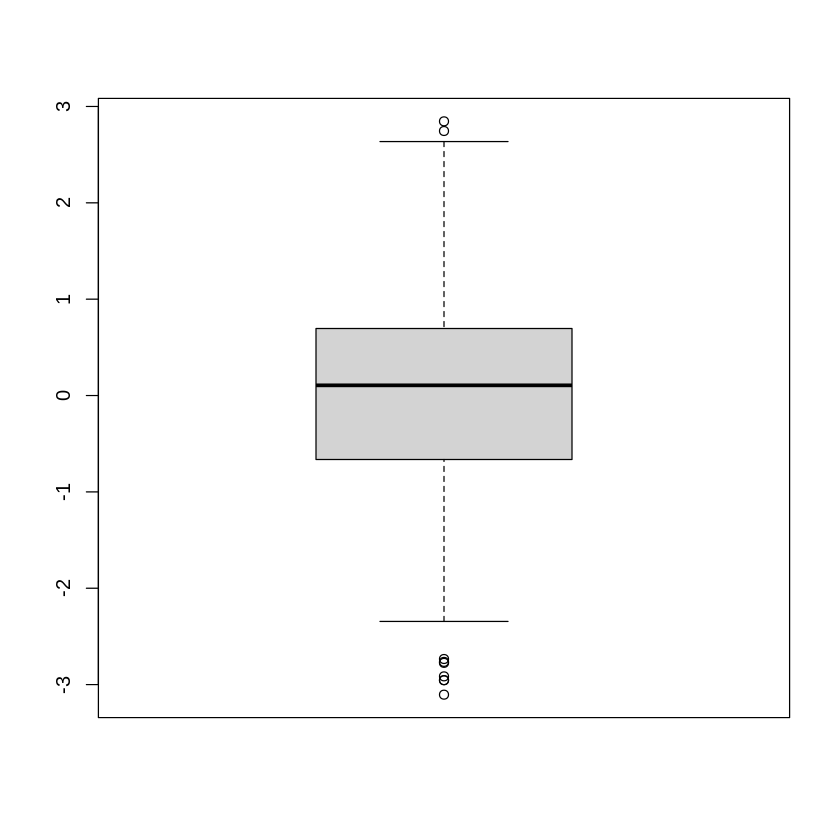

In [ ]:
boxplot(anova_result$residuals)

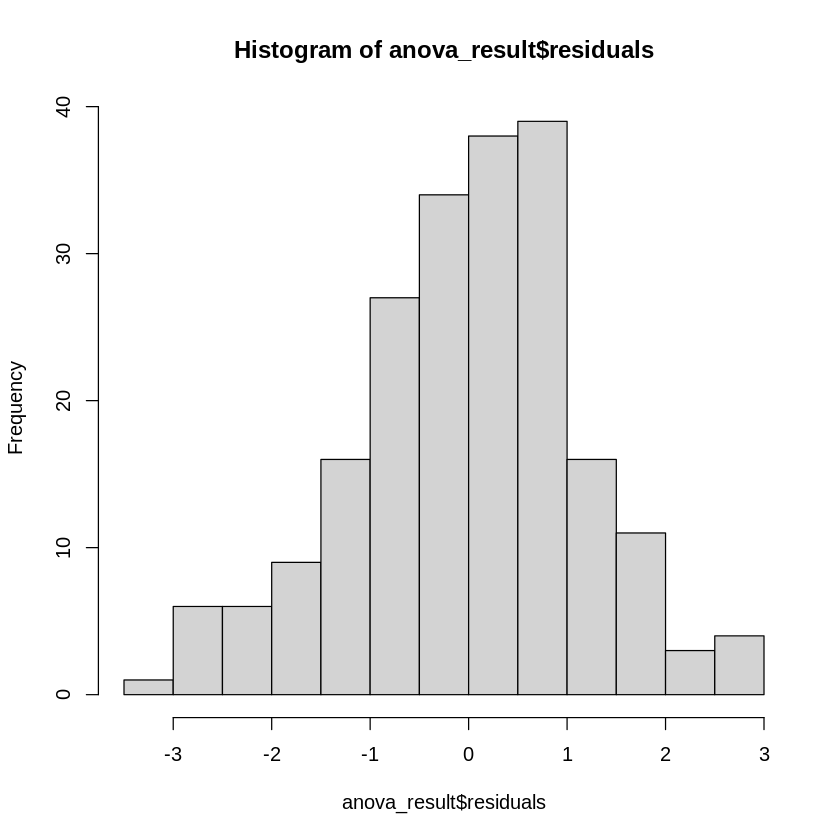

In [ ]:
hist(anova_result$residuals)

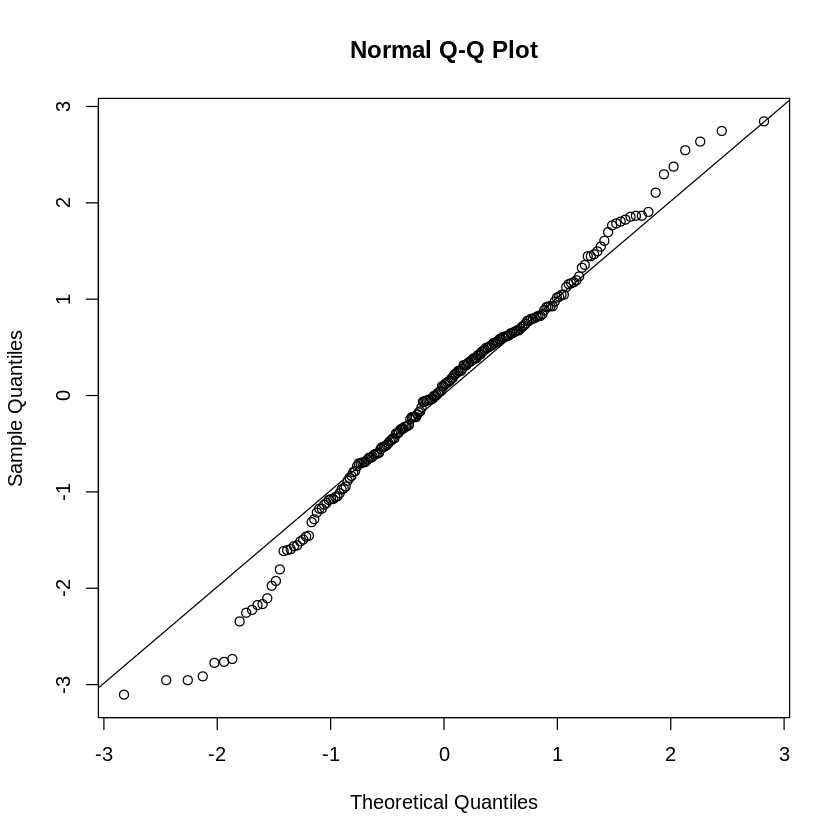

In [ ]:
qqnorm(anova_result$residuals)
qqline(anova_result$residuals)

# Homocedasticidad

Los gráficos y descriptivos nos informan si se verifica la igualdad de varianzas en los grupos descritos:

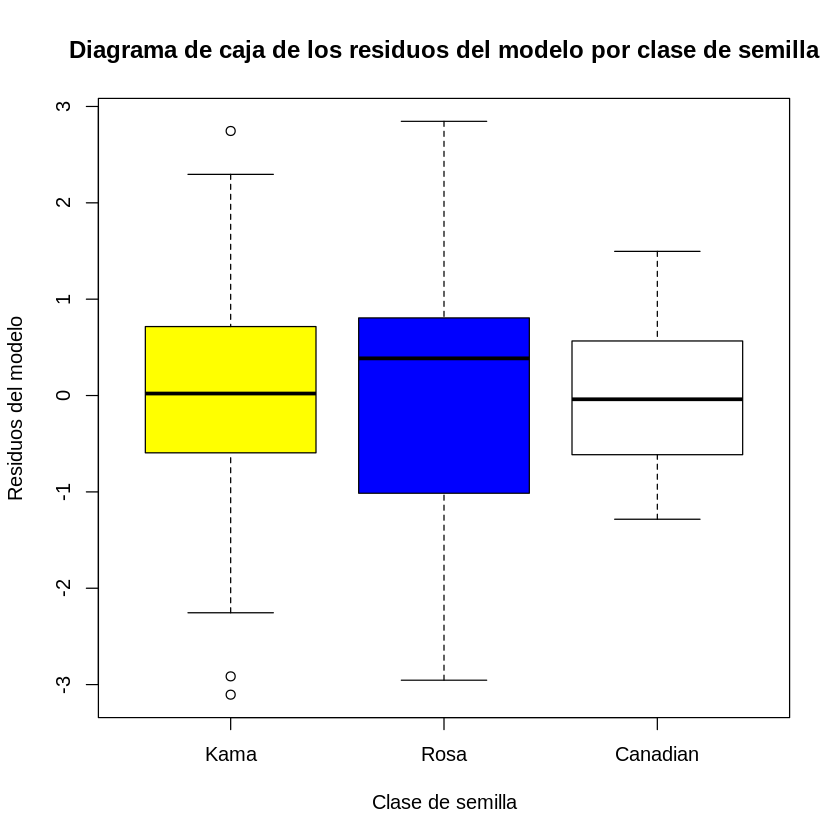

In [ ]:
colores <- c("yellow", "blue", "white")

# Crear el diagrama de caja de los residuos del modelo en función de los colores
boxplot(anova_result$residuals ~ seeds$class, col = colores,
        xlab = "Clase de semilla", ylab = "Residuos del modelo",
        main = "Diagrama de caja de los residuos del modelo por clase de semilla")

# Desviaciones

1) Desviaciones estándar de los residuos para cada grupo presente en la variable.

2) EL vector que contiene las desviaciones estándar de los residuos para cada grupo.

3) bartlett.test(): Prueba de Bartlett para evaluar si las varianzas de los residuos son iguales entre los grupos

4) La proporción (max(desviaciones) / min(desviaciones) ) indica la diferencia relativa entre las varianzas de los residuos en los distintos grupos. Si la razón es cercana a 1, significa que las varianzas de los residuos son relativamente similares entre los grupos. Si la razón es mucho mayor que 1, indica una mayor variabilidad entre las varianzas de los residuos en los grupos.

# ¿El test de Bartlett proporciona evidencia suficiente para afirmar que no podemos rechazar la hipótesis nula de que las varianzas son iguales?

In [ ]:
# Calcular las desviaciones estándar de los residuos para cada grupo de colores
desviaciones <- tapply(anova_result$residuals, seeds$class, sd)
max(desviaciones) / min(desviaciones)
bartlett.test(anova_result$residuals, seeds$class)


[1] 1.990995


	Bartlett test of homogeneity of variances

data:  anova_result$residuals and seeds$class
Bartlett's K-squared = 30.619, df = 2, p-value = 2.244e-07


# Kruskal-Wallis y pruebas post-hoc

In [ ]:
# Supongamos que tenemos un conjunto de datos 'seeds' con una variable continua 'area' y una variable categórica 'class' que representa los grupos
# Ejemplo de uso de kruskal.test
resultado_kruskal <- kruskal.test(area ~ class, data = seeds)

# Imprimir el resultado
print(resultado_kruskal)



	Kruskal-Wallis rank sum test

data:  area by class
Kruskal-Wallis chi-squared = 174, df = 2, p-value < 2.2e-16



# Si hemos detectado diferencias significativas en la variable respuesta para las distintas poblaciones. ¿Sería posible saber cuáles son los grupos que generan estas diferencias?

In [ ]:
# Realizar el test de Kruskal-Wallis
resultado_kruskal <- kruskal.test(area ~ class, data = seeds)

# Realizar comparaciones post-hoc utilizando la función pairwise.wilcox.test()
resultado_posthoc <- pairwise.wilcox.test(seeds$area, seeds$class, p.adjust.method = "bonferroni")

# Imprimir los resultados
print(resultado_posthoc)



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  seeds$area and seeds$class 

         Kama   Rosa  
Rosa     <2e-16 -     
Canadian <2e-16 <2e-16

P value adjustment method: bonferroni 


## Técnicas básicas

### Regresión lineal

In [ ]:
# Paso 1: Seleccionar variables predictoras y la variable de respuesta
variables_predictoras <- c("perimeter", "length", "width", "AC", "lengthGroove")  # Variables predictoras
variable_respuesta <- "area"  # Variable de respuesta

# Paso 2: Dividir los datos en conjuntos de entrenamiento y prueba
set.seed(123)  # Para reproducibilidad
indices_entrenamiento <- createDataPartition(seeds$area, p = 0.8, list = FALSE)
datos_entrenamiento <- seeds[indices_entrenamiento, ]
datos_prueba <- seeds[-indices_entrenamiento, ]

# Paso 3: Entrenar el modelo de regresión lineal
modelo <- lm(formula = paste(variable_respuesta, "~", paste(variables_predictoras, collapse = " + ")), data = datos_entrenamiento)

# Mostrar resumen del modelo
summary(modelo)



Call:
lm(formula = paste(variable_respuesta, "~", paste(variables_predictoras, 
    collapse = " + ")), data = datos_entrenamiento)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.30981 -0.07706 -0.00793  0.07234  0.41636 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -15.552375   0.161763 -96.143  < 2e-16 ***
perimeter      1.529360   0.080834  18.920  < 2e-16 ***
length        -0.170134   0.157289  -1.082 0.280989    
width          2.375521   0.128692  18.459  < 2e-16 ***
AC            -0.014257   0.007926  -1.799 0.073896 .  
lengthGroove   0.259340   0.069445   3.734 0.000259 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.131 on 164 degrees of freedom
Multiple R-squared:  0.9981,	Adjusted R-squared:  0.998 
F-statistic: 1.709e+04 on 5 and 164 DF,  p-value: < 2.2e-16


In [ ]:
# Crear un modelo de regresión lineal solo con las variables significativas
modelo_significativo <- lm(area ~ perimeter + width + lengthGroove, data = seeds)

# Imprimir el resumen del nuevo modelo
summary(modelo_significativo)



Call:
lm(formula = area ~ perimeter + width + lengthGroove, data = seeds)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.38175 -0.08258 -0.00136  0.07768  0.34984 

Coefficients:
              Estimate Std. Error  t value Pr(>|t|)    
(Intercept)  -15.72546    0.11446 -137.394  < 2e-16 ***
perimeter      1.45392    0.03915   37.139  < 2e-16 ***
width          2.50441    0.09285   26.971  < 2e-16 ***
lengthGroove   0.23005    0.05144    4.472 1.28e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1301 on 206 degrees of freedom
Multiple R-squared:  0.998,	Adjusted R-squared:  0.998 
F-statistic: 3.477e+04 on 3 and 206 DF,  p-value: < 2.2e-16


In [ ]:
# Predecir los valores de área utilizando el modelo con los datos de prueba
predicciones <- predict(modelo_significativo, newdata = datos_prueba)

# Comparar las predicciones con los valores reales en los datos de prueba
resultados <- data.frame(Real = datos_prueba$area, Prediccion = predicciones)
print(resultados)


     Real Prediccion
3   14.29   14.22742
6   14.38   14.36942
9   16.63   16.78186
16  14.59   14.48353
19  14.70   14.68447
21  14.16   14.23797
24  12.08   12.00407
25  15.01   15.01163
29  14.11   14.11676
40  14.28   14.28655
48  14.99   15.09145
54  14.33   14.24985
59  15.38   15.51277
60  12.11   12.49175
66  12.88   12.77350
75  16.82   16.89887
81  16.53   16.61309
86  18.27   18.23726
88  18.98   19.18282
90  20.88   20.61573
109 19.94   19.80572
111 18.45   18.48369
114 19.14   19.17555
119 18.89   18.68319
127 18.65   18.53791
131 18.30   18.15288
136 15.38   15.51797
137 17.36   17.51264
145 11.82   11.90296
157 11.34   11.27244
166 12.10   11.92213
180 12.21   12.29524
184 11.65   11.59609
186 11.56   11.53761
192 11.27   11.14474
195 12.11   12.17163
197 12.79   12.73508
200 12.76   12.74049
204 12.70   12.66293
205 12.37   12.42232


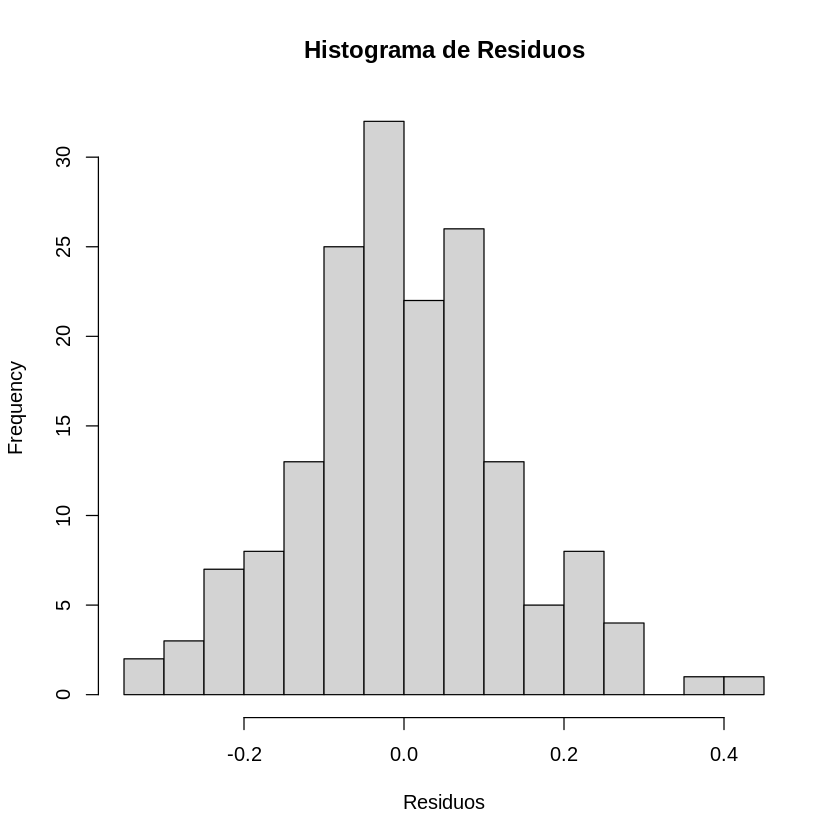

In [ ]:
# Ajustar el modelo de regresión lineal
modelo <- lm(area ~ perimeter + length + width + AC + lengthGroove, data = datos_entrenamiento)

# Obtener los residuos del modelo
residuos <- resid(modelo)

# Crear un histograma de los residuos
hist(residuos, breaks = 20, main = "Histograma de Residuos", xlab = "Residuos")


In [ ]:
# Ajustar modelo nulo
nulo <- lm(area ~ 1, data = numeric_seeds)
cat("===Modelo nulo===\n")
print(summary(nulo))

===Modelo nulo===

Call:
lm(formula = area ~ 1, data = numeric_seeds)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2575 -2.5775 -0.4925  2.4575  6.3325 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  14.8475     0.2008   73.95   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.91 on 209 degrees of freedom



In [ ]:
# Ajustar modelo completo .
completo <- lm(area ~ ., data = numeric_seeds)
cat("=== Modelo completo ===\ n")
print(summary(completo))

=== Modelo completo === n
Call:
lm(formula = area ~ ., data = numeric_seeds)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.26134 -0.06823 -0.00592  0.06901  0.40026 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -24.383345   1.034066 -23.580  < 2e-16 ***
perimeter      1.796960   0.070585  25.458  < 2e-16 ***
compactness   10.327081   1.206627   8.559 2.81e-15 ***
length        -0.115968   0.121776  -0.952    0.342    
width          0.945077   0.200322   4.718 4.43e-06 ***
AC             0.005240   0.006051   0.866    0.388    
lengthGroove   0.300892   0.050432   5.966 1.07e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1115 on 203 degrees of freedom
Multiple R-squared:  0.9986,	Adjusted R-squared:  0.9985 
F-statistic: 2.37e+04 on 6 and 203 DF,  p-value: < 2.2e-16



# Ajustar modelo con selección hacia adelante.

In [ ]:
adelante <- step(nulo , scope = list(upper = completo), direction = "forward", trace = 0)
cat("=== Modelo con selección hacia adelante ===\ n")
print(summary(adelante))
cat("AIC =", AIC(adelante), "\n\n")

=== Modelo con selecci ón hacia adelante === n
Call:
lm(formula = area ~ perimeter + compactness + lengthGroove + 
    width, data = numeric_seeds)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.26354 -0.06585 -0.00189  0.06761  0.40218 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -24.20199    0.97713 -24.768  < 2e-16 ***
perimeter      1.73119    0.04620  37.469  < 2e-16 ***
compactness   10.09882    1.15827   8.719 9.62e-16 ***
lengthGroove   0.30316    0.04483   6.762 1.39e-10 ***
width          1.04618    0.18518   5.649 5.33e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1114 on 205 degrees of freedom
Multiple R-squared:  0.9986,	Adjusted R-squared:  0.9985 
F-statistic: 3.559e+04 on 4 and 205 DF,  p-value: < 2.2e-16

AIC = -318.8303 



# Ajustar modelo con selección hacia atrás.

In [ ]:
atras <- step(nulo , scope = list(upper = completo), direction = "backward", trace = 0)
cat("=== Modelo con selección hacia atrás ===\ n")
print(summary(atras))
cat("AIC =", AIC(atras), "\n\n")

=== Modelo con selección hacia atrás === n
Call:
lm(formula = area ~ 1, data = numeric_seeds)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2575 -2.5775 -0.4925  2.4575  6.3325 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  14.8475     0.2008   73.95   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.91 on 209 degrees of freedom

AIC = 1047.533 



# Ajustar modelo con regresión escalonada .

In [ ]:
escalonado <- step(nulo , scope = list(lower=nulo, upper=completo), direction = "both", trace=0)
cat ("=== Modelo con regresión escalonada ===\ n")
print (summary(escalonado))
cat("AIC =", AIC(escalonado), "\n\n")

=== Modelo con regresión escalonada === n
Call:
lm(formula = area ~ perimeter + compactness + lengthGroove + 
    width, data = numeric_seeds)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.26354 -0.06585 -0.00189  0.06761  0.40218 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -24.20199    0.97713 -24.768  < 2e-16 ***
perimeter      1.73119    0.04620  37.469  < 2e-16 ***
compactness   10.09882    1.15827   8.719 9.62e-16 ***
lengthGroove   0.30316    0.04483   6.762 1.39e-10 ***
width          1.04618    0.18518   5.649 5.33e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1114 on 205 degrees of freedom
Multiple R-squared:  0.9986,	Adjusted R-squared:  0.9985 
F-statistic: 3.559e+04 on 4 and 205 DF,  p-value: < 2.2e-16

AIC = -318.8303 



# Ajustar modelo con todos los subconjuntos .

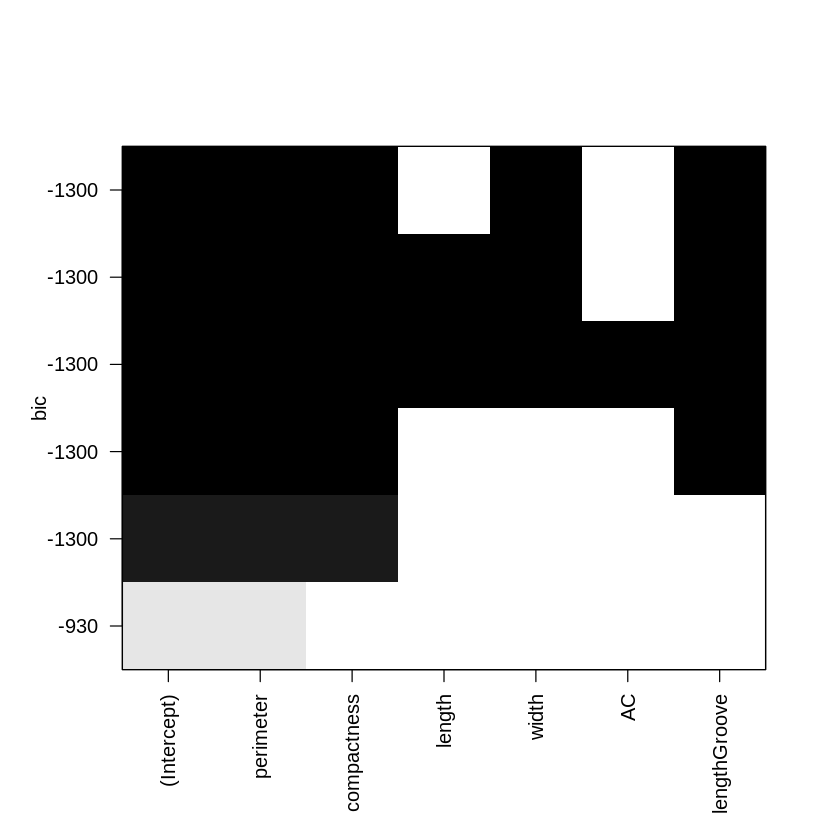

In [ ]:
modelos <- regsubsets(area ~ ., data = numeric_seeds , method = "exhaustive", nbest=1, nvmax=10)
plot(modelos, cex.axis = 0.7, cex.lab = 0.8, cex.main = 0.9)

# EVALUACIÓN DE UN MODELO DE RLM

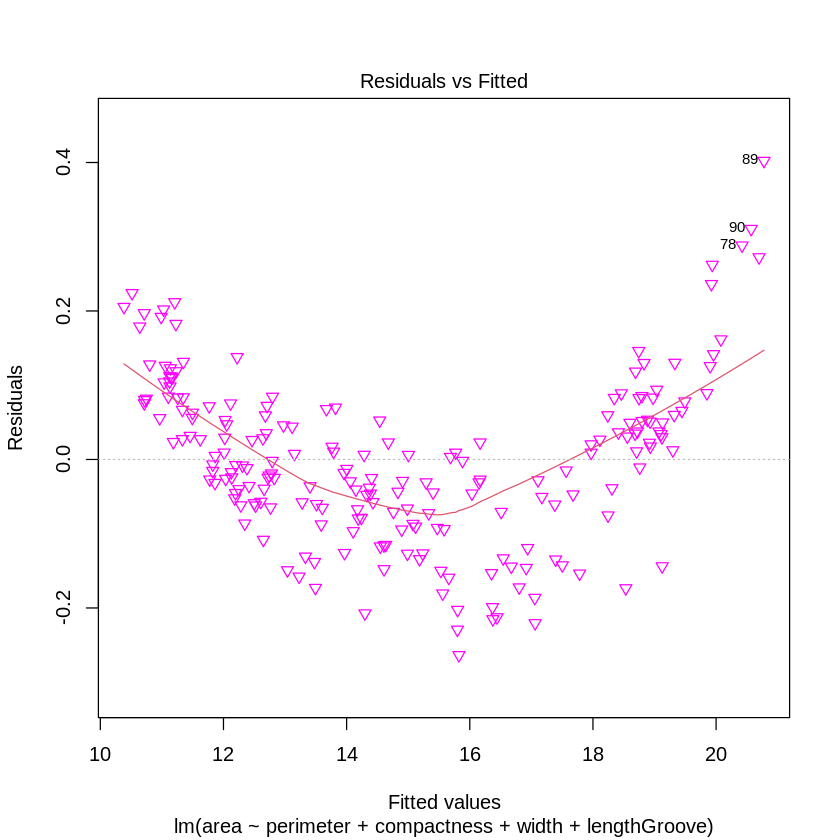

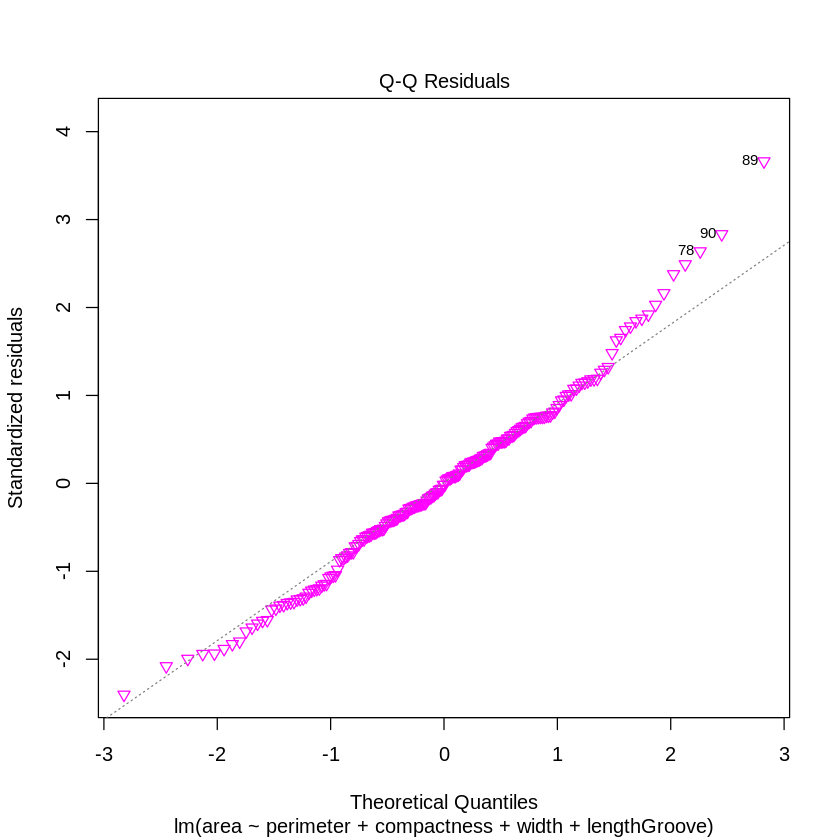

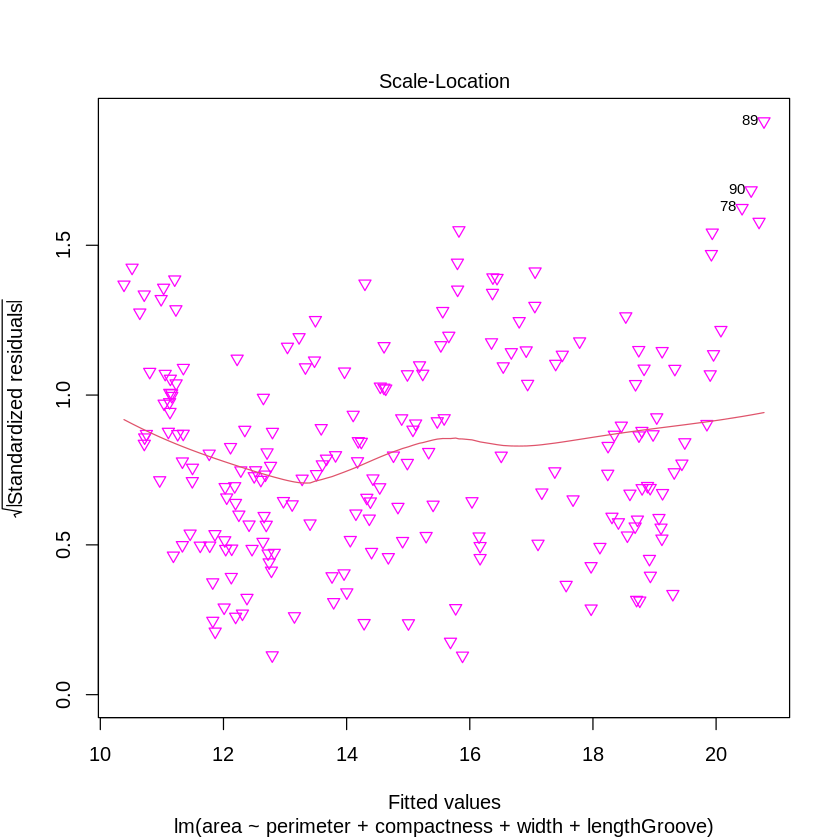

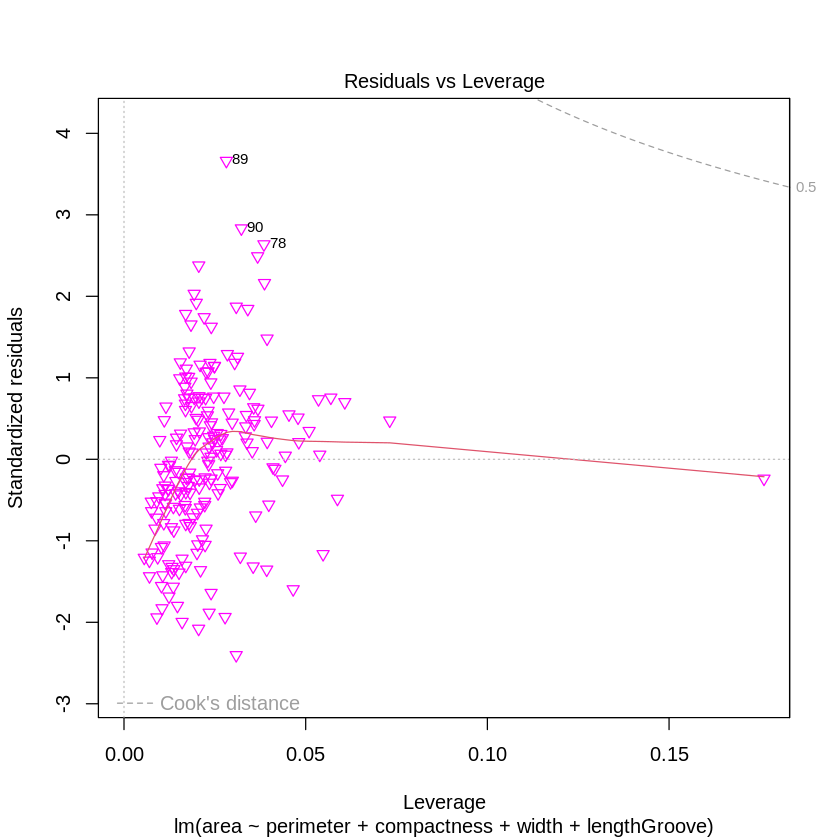

In [ ]:
# Ajustar modelo final.
modelo <- lm(area ~ perimeter + compactness + width + lengthGroove, data = numeric_seeds)
plot(modelo, col = "magenta", pch = 6)

In [ ]:
predictores <- names(coef(modelo))[-1]
datos <- numeric_seeds[, c(predictores, "area")]
resultados <- data.frame(respuesta_predicha = fitted(modelo))

# Residuo estandarizado: los residuos deben seguir una distribución normal estándar, por lo que se esperaría que el 95% de ellos se encuentre entre -1,96 y 1,96, y el 99% entre -2,58 y 2,58.

In [ ]:
resultados[["residuos_estandarizados"]] <- rstandard(modelo)
cat ("Identificación de valores atípicos :\n")
residuos_estandarizados <- which(abs(resultados[["residuos_estandarizados"]]) > 1.96)
cat("- Residuos estandarizados fuera del 95 % esperado :", residuos_estandarizados , "\n")
# Crear un histograma de los residuos


Identificación de valores atípicos :
- Residuos estandarizados fuera del 95 % esperado : 72 78 83 89 90 115 129 135 138 178 


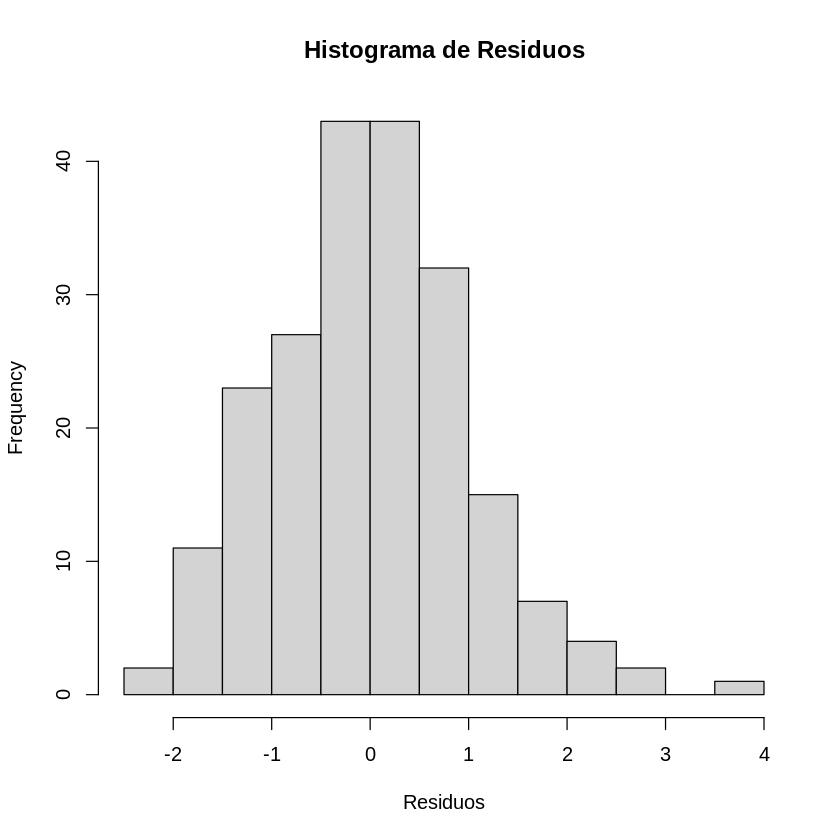

In [ ]:
hist(resultados[["residuos_estandarizados"]], breaks = 20, main = "Histograma de Residuos", xlab = "Residuos")

# Gráfico de influencia

# La primera observación tiene un valor de -0.2371781 en StudRes, lo que significa que está aproximadamente 0.24 desviaciones estándar por debajo de la recta de regresión. **Hat** es una matriz que, proyecta los valores observados en el espacio de las variables predictoras para obtener los valores ajustados. Calcula cuánto impacto tiene cada observación en los valores que el modelo predice para los datos observados. **CookD** Mide cómo cambian los valores ajustados y los coeficientes de regresión cuando una observación se elimina del modelo.

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
60,-0.2371781,0.17612798,0.002416305
78,2.6777772,0.03850998,0.055760684
89,3.7788123,0.02817411,0.077757708
90,2.8835673,0.03230046,0.053595905
98,0.4749843,0.07313186,0.003573723


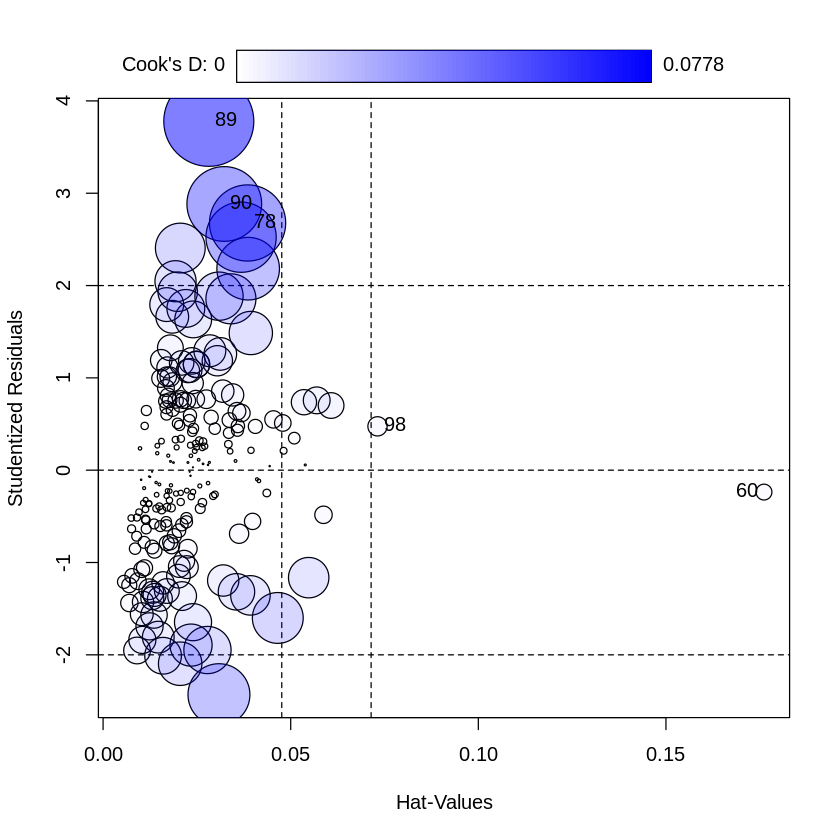

In [ ]:
influencePlot(modelo)

In [ ]:
#plot(influencePlot(modelo), main = "Gráfico de influencia del modelo")[1]

In [ ]:
resultados[["distancia_Cook"]] <- cooks.distance(modelo)
# Observaciones con distancia de Cook mayor a uno.
distancia_Cook <- which(resultados[["distancia_Cook"]] > 1)
cat ("- Residuos con una distancia de Cook alta :", distancia_Cook , "\n")

- Residuos con una distancia de Cook alta :  
